# Response Time Estimate Validation



In [39]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


In [40]:
def find_project_root():
    """Find the project root without using an absolute path."""
    current = Path.cwd().resolve()

    for candidate in [current] + list(current.parents):
        if (
            (candidate / "experiment_results").exists()
            and (
                (candidate / "src").exists()
                or (candidate / "simulator.py").exists()
            )
        ):
            return candidate

    raise FileNotFoundError(
        "Project root was not found. Please run this notebook from inside the project folder."
    )


PROJECT_ROOT = find_project_root()

RESULT_DIR = (
    PROJECT_ROOT
    / "experiment_results"
    / "response_time_validation"
)

FIGURE_DIR = (
    PROJECT_ROOT
    / "Figs"
    / "response_time_estimate_validation"
)

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RAW_RESULT_PATH = RESULT_DIR / "response_time_validation_raw.csv"
SUMMARY_RESULT_PATH = RESULT_DIR / "response_time_validation_summary.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULT_DIR:", RESULT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)

PROJECT_ROOT: C:\Users\caoxb\PycharmProjects\ATM_simulation
RESULT_DIR: C:\Users\caoxb\PycharmProjects\ATM_simulation\experiment_results\response_time_validation
FIGURE_DIR: C:\Users\caoxb\PycharmProjects\ATM_simulation\Figs\response_time_estimate_validation


In [41]:
raw_results = pd.read_csv(RAW_RESULT_PATH)
summary_results = pd.read_csv(SUMMARY_RESULT_PATH)

required_raw_columns = [
    "load_scenario",
    "response_time_direct",
    "response_time_little",
]

required_summary_columns = [
    "load_scenario",
    "simulation_horizon",
    "mean_relative_difference_percent",
]

missing_raw_columns = [
    column for column in required_raw_columns
    if column not in raw_results.columns
]

missing_summary_columns = [
    column for column in required_summary_columns
    if column not in summary_results.columns
]

if missing_raw_columns:
    raise KeyError(f"Missing columns in raw results: {missing_raw_columns}")

if missing_summary_columns:
    raise KeyError(f"Missing columns in summary results: {missing_summary_columns}")

raw_plot_df = raw_results[required_raw_columns].copy()
summary_plot_df = summary_results[required_summary_columns].copy()

In [42]:
FIGSIZE = (6, 5)
DPI = 300
AX_BOX_ASPECT = 1


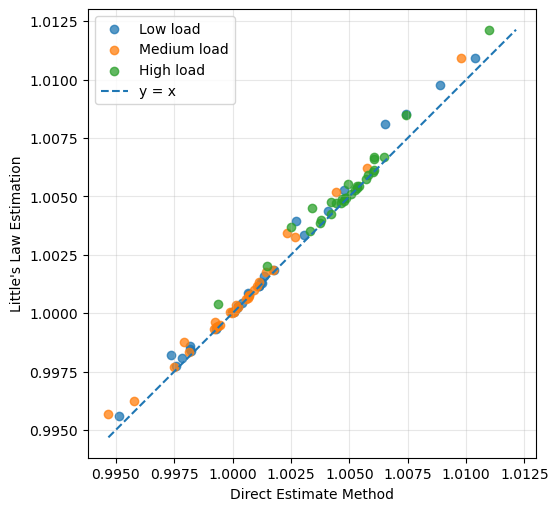

In [43]:
fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

for load_scenario, group in raw_plot_df.groupby("load_scenario", sort=False):
    ax.scatter(
        group["response_time_direct"],
        group["response_time_little"],
        alpha=0.75,
        label=load_scenario,
    )

minimum_value = min(
    raw_plot_df["response_time_direct"].min(),
    raw_plot_df["response_time_little"].min(),
)

maximum_value = max(
    raw_plot_df["response_time_direct"].max(),
    raw_plot_df["response_time_little"].max(),
)

ax.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    label="y = x",
)

ax.set_xlabel("Direct Estimate Method")
ax.set_ylabel("Little's Law Estimation")
ax.grid(alpha=0.3)
ax.legend()

ax.set_box_aspect(AX_BOX_ASPECT)

plt.savefig(
    FIGURE_DIR / "estimate_compare_scatter.png",
    dpi=DPI,
)

plt.show()

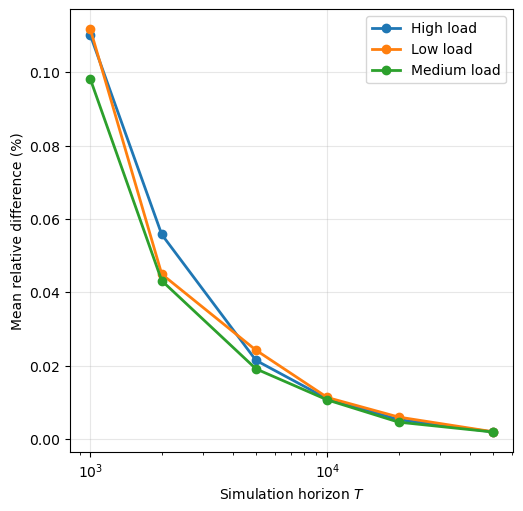

In [44]:
fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)

for load_scenario, group in summary_plot_df.groupby("load_scenario", sort=False):
    ordered_group = group.sort_values("simulation_horizon")

    ax.plot(
        ordered_group["simulation_horizon"],
        ordered_group["mean_relative_difference_percent"],
        marker="o",
        linewidth=2,
        label=load_scenario,
    )

ax.set_xscale("log")
ax.set_xlabel("Simulation horizon $T$")
ax.set_ylabel("Mean relative difference (%)")
ax.grid(alpha=0.3)
ax.legend()

ax.set_box_aspect(AX_BOX_ASPECT)

plt.savefig(
    FIGURE_DIR / "estimate_compare_line.png",
    dpi=DPI,
)

plt.show()